# Importación de librerias necesarias

In [10]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

Prophet para su funcionamiento requiere: 

- La columna de fechas debe llamarse ds (Date Stamp)
- La columna de lo que se quiere predecir se debe llamar y (en este caso, el objetivo será el saldo)


# Carga fichero y preparación del os datos

In [11]:
# Carga del fichero
datos = pd.read_csv('tesoreria_r.csv')

# Preparación de los datos para Prophet (renombramiento de columnas) y nos quedamos con la fecha y saldo bancario
df = datos[['Fecha', 'Saldo_Bancario']].copy()
df = df.rename(columns={'Fecha': 'ds', 'Saldo_Bancario': 'y'})

# Inicialización del modelo - Fase de búsqueda de patrones diarios y anuales

In [12]:
modelo = Prophet(daily_seasonality=False, yearly_seasonality=True)

Fase de entrenamiento

In [13]:
print("Entrenando el modelo...(puede tardar unos segundos)")
modelo.fit(df)

16:58:06 - cmdstanpy - INFO - Chain [1] start processing
16:58:06 - cmdstanpy - INFO - Chain [1] done processing


Entrenando el modelo...(puede tardar unos segundos)


# Creación predicción: generaremos información para los próximos 60 días

In [14]:
futuro = modelo.make_future_dataframe(periods=60)

Fase Predicción

In [15]:
prediccion = modelo.predict(futuro)

# Visualización de los resultado con Prophet integrado

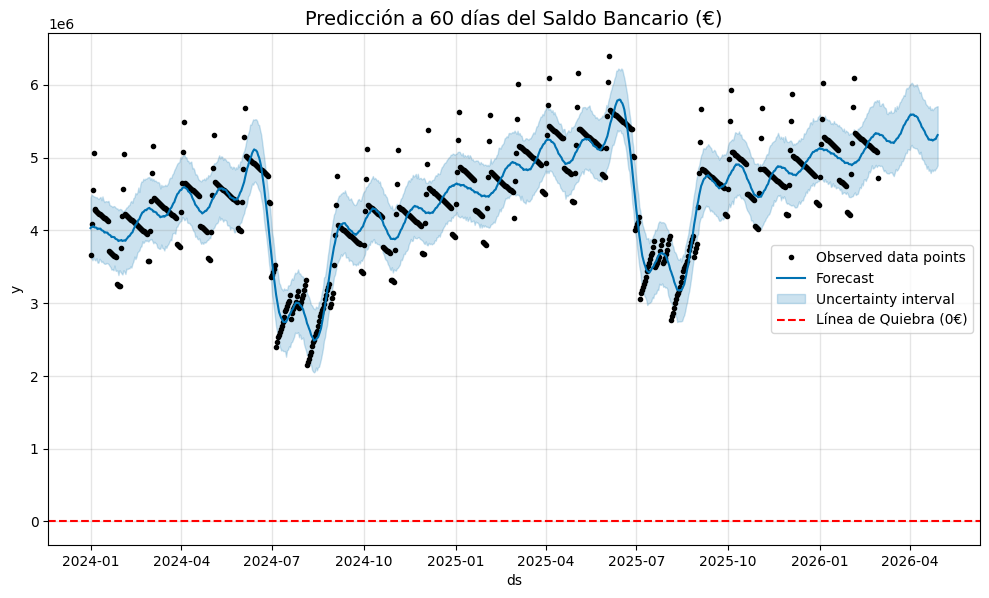

In [16]:
fig1 = modelo.plot(prediccion)
plt.title('Predicción a 60 días del Saldo Bancario (€)', fontsize=14)
plt.axhline(0, color='red', linestyle='--', label='Línea de Quiebra (0€)')
plt.legend()
plt.show()

Vemos detalle de los componentes (Tendencia general vs Estacionalidad de la semana)

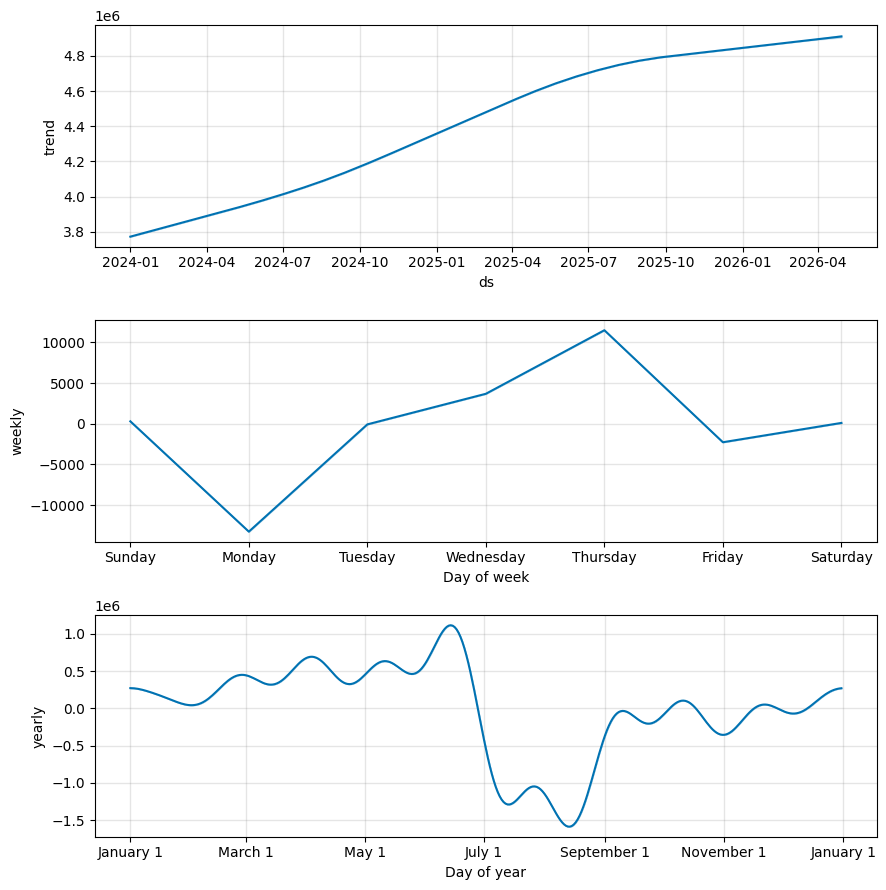

In [17]:
fig2 = modelo.plot_components(prediccion)
plt.show()

## CONCLUSIONES
- Predicción 60 días: El modelo ha proyectado la liquidez para marzo y abril de 2026. El saldo se mantiene sólidamente por encima de los 4,5M€. Esta predicción confirma una posición de caja muy segura a corto plazo para afrontar las obligaciones.

- Crecimiento (Gráfico Trend): Se observa una tendencia incremental suave y sostenida (pasando de 3,8M€ a 4,8M€ en dos años). Esto indica que el modelo de negocio es estructuralmente rentable y genera caja, aunque los márgenes no permiten excesos y exigen un control continuo. 

- Descenso grande en verano (Gráfico Yearly): A pesar de las fluctuaciones normales durante el curso (pagos de IVA y nóminas), la caja sufre una contracción drástica entre finales de junio y principios de julio. Este valle de liquidez responde a dos factores clave: la salida de 1M€ por reparto de dividendos y la caída de ingresos recurrentes. 